# Introduction to Signals & Signal Processing
---

This notebook builds the foundational intuition for **signal processing**
---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# 1. What is a Signal?
---

> **A signal is any quantity measured at regular intervals.**

Signals are everywhere — audio waveforms, stock prices, temperature readings, and of course, brain electrical activity (EEG). At its core, a signal is just a sequence of numbers that encode how something changes over time (or space).

### Continuous vs Discrete Signals

| Property | Continuous Signal | Discrete Signal |
|---|---|---|
| **Definition** | Defined at **every** instant in time | Defined only at **specific** time points |
| **Representation** | $s(t)$, where $t \in \mathbb{R}$ | $s[n]$, where $n \in \mathbb{Z}$ |
| **Example** | Voltage from an electrode | Digitized EEG after A/D conversion |

In practice, we almost always work with **discrete** signals — continuous real-world phenomena are **sampled** at regular time intervals by our recording equipment.

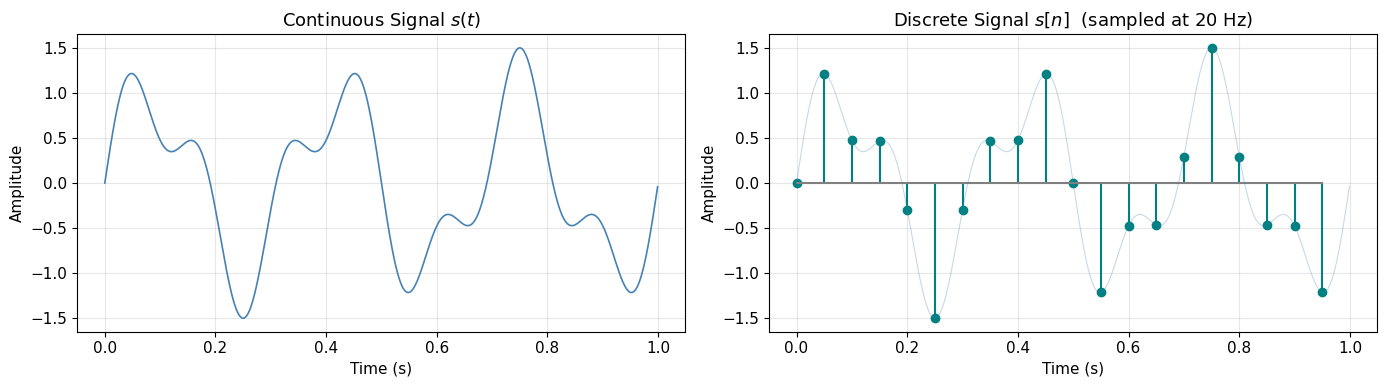

In [3]:
# Continuous vs Discrete signal visualization
fs_high = 1000  # "continuous" approximation
fs_low = 20     # discrete sampling

t_cont = np.arange(0, 1, 1/fs_high)
t_disc = np.arange(0, 1, 1/fs_low)

signal_cont = np.sin(2 * np.pi * 3 * t_cont) + 0.5 * np.sin(2 * np.pi * 7 * t_cont)
signal_disc = np.sin(2 * np.pi * 3 * t_disc) + 0.5 * np.sin(2 * np.pi * 7 * t_disc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_cont, signal_cont, color='steelblue', linewidth=1.2)
axes[0].set_title('Continuous Signal $s(t)$', fontsize=13)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

axes[1].stem(t_disc, signal_disc, linefmt='teal', markerfmt='o', basefmt='gray')
axes[1].plot(t_cont, signal_cont, color='steelblue', alpha=0.3, linewidth=0.8)
axes[1].set_title(f'Discrete Signal $s[n]$  (sampled at {fs_low} Hz)', fontsize=13)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# 2. Key Terminology
---

### Sampling Rate ($f_s$)

The **sampling rate** (or sampling frequency) is the number of samples captured per second, measured in **Hertz (Hz)**.

- A sampling rate of 256 Hz means 256 data points per second.
- It is also related to zero-crossings: the number of zero-crossings per second $\times$ 0.5 gives the dominant frequency.

### Frequency and Period

$$f = \frac{1}{T}$$

where:
- $f$ is the **frequency**: cycles per second (Hz),
- $T$ is the **period**: the duration of one complete cycle (seconds).

| Concept | Symbol | Unit | Meaning |
|---|---|---|---|
| Frequency | $f$ | Hz | How many cycles occur per second |
| Period | $T$ | seconds | How long one cycle takes |
| Sampling rate | $f_s$ | Hz | How many measurements per second |
| Sample interval | $\Delta t = 1/f_s$ | seconds | Time between consecutive samples |

In [4]:
# Interactive: explore frequency and period
def plot_frequency_period(freq=3.0):
    fs = 1000
    t = np.arange(0, 2, 1/fs)
    s = np.sin(2 * np.pi * freq * t)
    T = 1 / freq

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, s, color='steelblue', linewidth=1.5)

    # Highlight one period
    ax.axvspan(0, T, alpha=0.15, color='orange', label=f'One period T = {T:.3f} s')
    ax.axvline(T, color='orange', linestyle='--', alpha=0.7)

    # Mark zero crossings in first two periods
    zero_crossings = [0, T/2, T, 3*T/2, 2*T]
    for zc in zero_crossings:
        if zc <= 2:
            ax.plot(zc, 0, 'ro', markersize=6, zorder=5)

    ax.set_title(f'Frequency = {freq:.1f} Hz  |  Period T = {T:.4f} s', fontsize=13)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 2)
    plt.tight_layout()
    plt.show()

interact(
    plot_frequency_period,
    freq=FloatSlider(min=0.5, max=15, step=0.5, value=3, description='Frequency (Hz)')
)

interactive(children=(FloatSlider(value=3.0, description='Frequency (Hz)', max=15.0, min=0.5, step=0.5), Outpu…

<function __main__.plot_frequency_period(freq=3.0)>

# 3. Properties of Oscillations
---

Any oscillation is fully characterized by **three quantities**:

| Property | Question it answers | Unit |
|---|---|---|
| **Frequency** | How fast does it oscillate? | Hz |
| **Amplitude / Power** | How strong is it? | μV / μV² |
| **Phase** | When does the cycle start? (amplitude at $t = 0$) | radians |

Together, these three numbers can reconstruct any pure sinusoidal signal. This is the fundamental insight behind the **Fourier Transform** — any complex signal can be decomposed into a sum of sinusoids, each described by its frequency, amplitude, and phase.

In [5]:
# Interactive: explore amplitude, frequency, and phase
def plot_oscillation(amplitude=1.0, frequency=3.0, phase=0.0):
    fs = 1000
    t = np.arange(0, 2, 1/fs)
    s = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, s, color='steelblue', linewidth=1.5)

    # Reference: unit sine at same frequency
    ref = np.sin(2 * np.pi * frequency * t)
    ax.plot(t, ref, color='gray', alpha=0.3, linewidth=1, linestyle='--', label='Reference (a=1, phase=0)')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(amplitude, color='red', linewidth=0.8, linestyle=':', alpha=0.6, label=f'Peak = {amplitude}')
    ax.axhline(-amplitude, color='red', linewidth=0.8, linestyle=':', alpha=0.6)

    ax.set_title(f'a = {amplitude:.1f}  |  f = {frequency:.1f} Hz  |  phase = {phase:.2f} rad ({np.degrees(phase):.0f} deg)', fontsize=13)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-5.5, 5.5)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

interact(
    plot_oscillation,
    amplitude=FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Amplitude'),
    frequency=FloatSlider(min=0.5, max=15, step=0.5, value=3.0, description='Freq (Hz)'),
    phase=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='Phase (rad)')
)

interactive(children=(FloatSlider(value=1.0, description='Amplitude', max=5.0, min=0.1), FloatSlider(value=3.0…

<function __main__.plot_oscillation(amplitude=1.0, frequency=3.0, phase=0.0)>

# 4. Amplitude Measures
---

There are several ways to quantify the "strength" of a signal. Each captures a different aspect:

### Peak Amplitude
The maximum absolute value of the signal.
- Measures the strength of **individual EEG components** (e.g., amplitude of an ERP or spike).
- Useful for detecting **abnormal spikes** (e.g., epileptic discharges).

### Peak-to-Peak Amplitude
The difference between the maximum and minimum values of the signal.
- Reflects the **overall variability** of the EEG signal (e.g., alpha or beta wave amplitude).
- Used to assess **signal-to-noise ratio** or amplitude modulation in brain rhythms.

$$A_{p2p} = \max(s) - \min(s)$$

### RMS Amplitude (Root Mean Square)
A statistical measure of the magnitude of a varying signal. It calculates the square root of the average of the squared values over a time window, providing a single value that represents the **effective amplitude** — accounting for both positive and negative fluctuations.

For a discrete signal $s$ with $N$ samples:

$$A_{\text{RMS}} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} s_i^2}$$

where:
- $s_i$ is the amplitude of the signal at sample $i$,
- $N$ is the total number of samples.

| Measure | What it captures | Best for |
|---|---|---|
| Peak | Maximum excursion | Spike detection, ERPs |
| Peak-to-peak | Total range of variation | SNR, oscillation strength |
| RMS | Effective average magnitude | Overall signal power, comparing conditions |

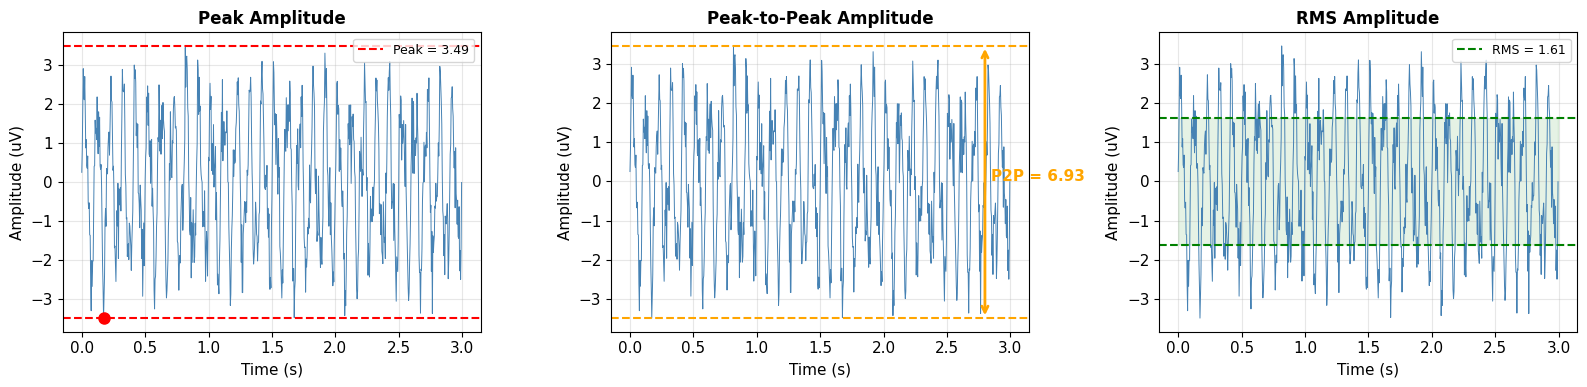

Peak Amplitude:      3.485 uV
Peak-to-Peak:        6.933 uV
RMS Amplitude:       1.613 uV


In [6]:
# Demonstrate all three amplitude measures on a realistic signal
np.random.seed(42)
fs = 256
t = np.arange(0, 3, 1/fs)

# Composite signal: alpha + beta + noise
signal = (
    2.0 * np.sin(2 * np.pi * 10 * t)       # alpha
    + 0.8 * np.sin(2 * np.pi * 22 * t)     # beta
    + 0.5 * np.random.randn(len(t))         # noise
)

peak_amp = np.max(np.abs(signal))
peak_to_peak = np.max(signal) - np.min(signal)
rms_amp = np.sqrt(np.mean(signal**2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Peak amplitude
axes[0].plot(t, signal, color='steelblue', linewidth=0.7)
idx_peak = np.argmax(np.abs(signal))
axes[0].axhline(peak_amp, color='red', linestyle='--', label=f'Peak = {peak_amp:.2f}')
axes[0].axhline(-peak_amp, color='red', linestyle='--')
axes[0].plot(t[idx_peak], signal[idx_peak], 'ro', markersize=8, zorder=5)
axes[0].set_title('Peak Amplitude', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Peak-to-peak
axes[1].plot(t, signal, color='steelblue', linewidth=0.7)
axes[1].axhline(np.max(signal), color='orange', linestyle='--')
axes[1].axhline(np.min(signal), color='orange', linestyle='--')
axes[1].annotate('', xy=(2.8, np.max(signal)), xytext=(2.8, np.min(signal)),
                 arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
axes[1].text(2.85, 0, f'P2P = {peak_to_peak:.2f}', color='orange', fontsize=11, fontweight='bold')
axes[1].set_title('Peak-to-Peak Amplitude', fontsize=12, fontweight='bold')

# RMS
axes[2].plot(t, signal, color='steelblue', linewidth=0.7)
axes[2].axhline(rms_amp, color='green', linestyle='--', label=f'RMS = {rms_amp:.2f}')
axes[2].axhline(-rms_amp, color='green', linestyle='--')
axes[2].fill_between(t, -rms_amp, rms_amp, alpha=0.1, color='green')
axes[2].set_title('RMS Amplitude', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (uV)')

plt.tight_layout()
plt.show()

print(f'Peak Amplitude:      {peak_amp:.3f} uV')
print(f'Peak-to-Peak:        {peak_to_peak:.3f} uV')
print(f'RMS Amplitude:       {rms_amp:.3f} uV')

In [7]:
# Interactive: sliding window RMS to see how amplitude varies over time
def plot_sliding_rms(window_ms=200):
    np.random.seed(42)
    fs = 256
    t = np.arange(0, 4, 1/fs)

    # Signal with amplitude modulation (mimics EEG alpha bursting)
    envelope = 1 + 1.5 * np.exp(-((t - 2.0)**2) / (2 * 0.3**2))
    signal = envelope * np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))

    # Compute sliding-window RMS
    win_samples = int(window_ms / 1000 * fs)
    rms = np.array([
        np.sqrt(np.mean(signal[max(0, i - win_samples//2):i + win_samples//2]**2))
        for i in range(len(signal))
    ])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, signal, color='steelblue', alpha=0.5, linewidth=0.6, label='Signal')
    ax.plot(t, rms, color='red', linewidth=2, label=f'Sliding RMS ({window_ms} ms window)')
    ax.plot(t, -rms, color='red', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (uV)')
    ax.set_title('Sliding-Window RMS Amplitude', fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

interact(
    plot_sliding_rms,
    window_ms=IntSlider(min=50, max=1000, step=50, value=200, description='Window (ms)')
)

interactive(children=(IntSlider(value=200, description='Window (ms)', max=1000, min=50, step=50), Output()), _…

<function __main__.plot_sliding_rms(window_ms=200)>

# 5. Noise
---

Noise is any unwanted signal component that contaminates the measurement. Understanding noise is critical because **all real signals are noisy**, and many signal processing techniques are fundamentally about separating signal from noise.

### White Noise
**Equal power at all frequencies** — the spectrum is flat. It can be:

- **Gaussian (normally distributed):** Amplitudes follow a bell curve $\mathcal{N}(0, \sigma^2)$. Most common model for electronic/thermal noise.
- **Uniform:** Amplitudes are equally likely across a range. Less common but useful as a reference.

### Pink Noise (1/f Noise)
Power **decreases** with increasing frequency, following a $1/f$ characteristic. This means:
- Low frequencies are loud, high frequencies are quiet.
- **Very common in biological signals**, including EEG — the brain's background activity has a natural $1/f$ spectrum.

| Noise Type | Spectrum Shape | Amplitude Distribution | Where Found |
|---|---|---|---|
| Gaussian White | Flat | Normal (bell curve) | Electronics, thermal |
| Uniform White | Flat | Uniform (rectangular) | Quantization, simulation |
| Pink (1/f) | $\propto 1/f$ | Varies | Biological signals, EEG |

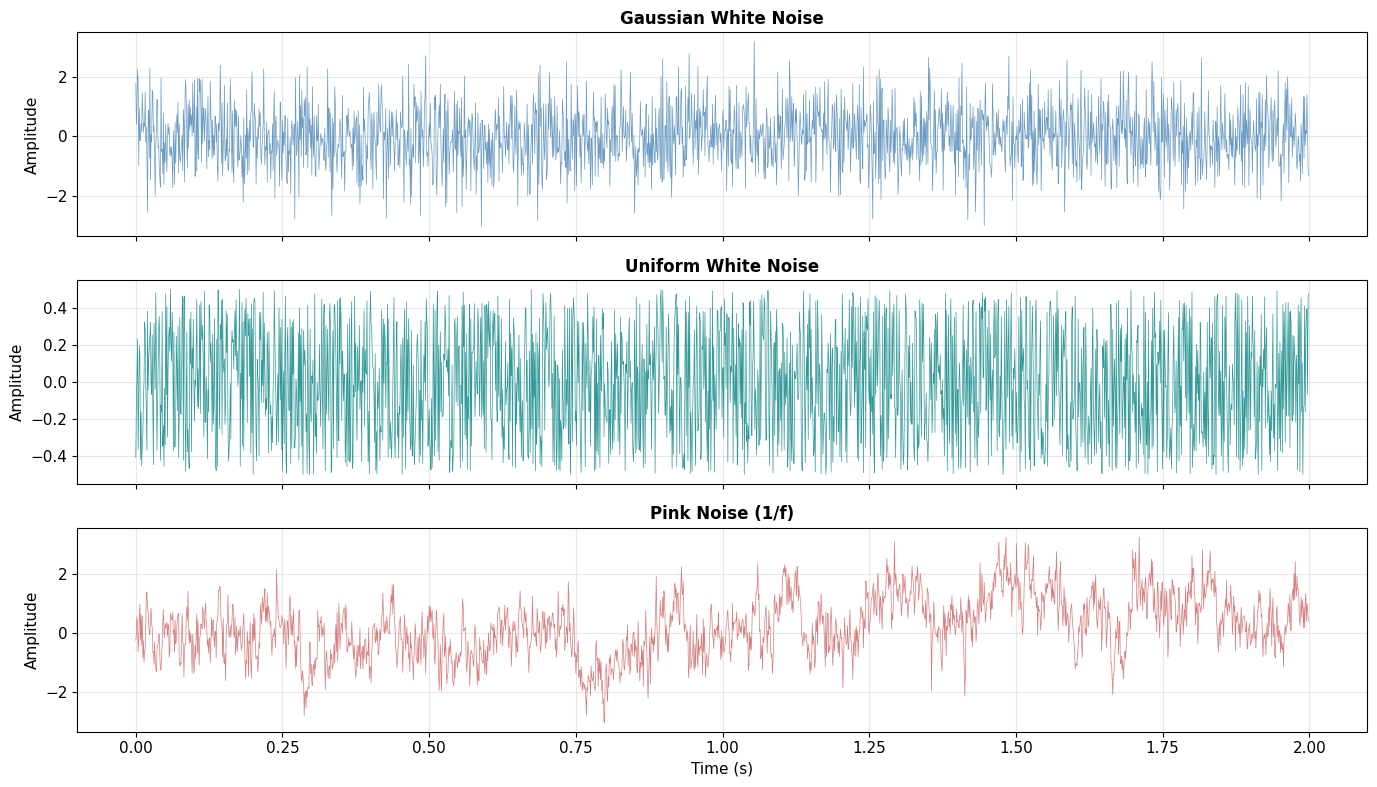

In [8]:
# Generate and compare noise types
np.random.seed(0)
fs = 1000
duration = 10
t = np.arange(0, duration, 1/fs)
n = len(t)

# Gaussian white noise
gwn = np.random.randn(n)

# Uniform white noise (shifted to zero-mean)
uwn = np.random.rand(n) - 0.5

# Pink noise (1/f): shape white noise spectrum
white_fft = np.fft.rfft(np.random.randn(n))
freqs = np.fft.rfftfreq(n, d=1/fs)
freqs[0] = 1  # avoid division by zero
pink_fft = white_fft / np.sqrt(freqs)
pink = np.fft.irfft(pink_fft, n=n)
pink /= np.std(pink)  # normalize

noises = [('Gaussian White Noise', gwn, 'steelblue'),
          ('Uniform White Noise', uwn, 'teal'),
          ('Pink Noise (1/f)', pink, 'indianred')]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, (title, noise, color) in zip(axes, noises):
    ax.plot(t[:2000], noise[:2000], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

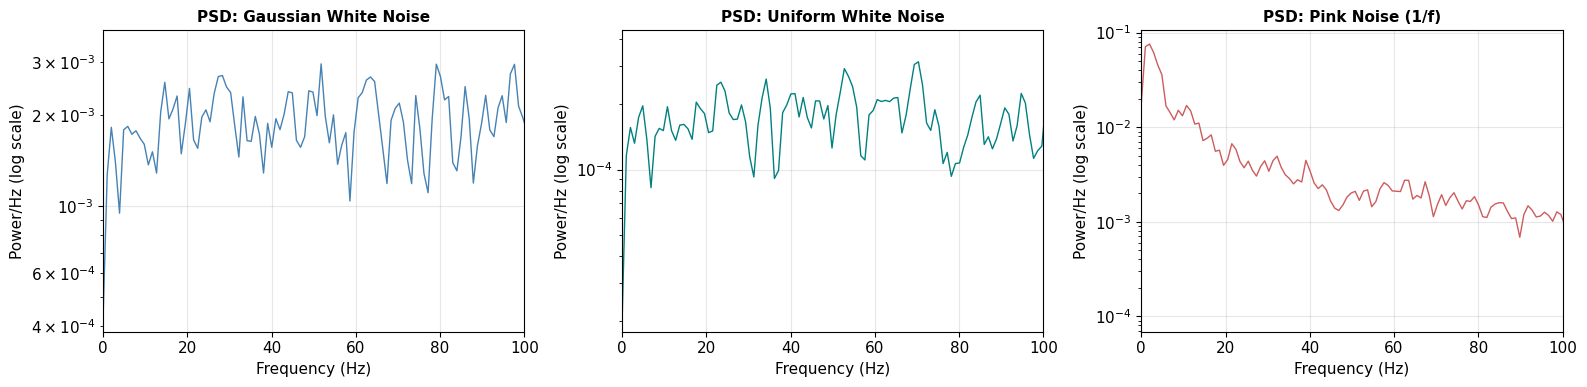

In [9]:
# Power Spectral Density comparison
from scipy.signal import welch

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, noise, color) in zip(axes, noises):
    f_psd, psd = welch(noise, fs=fs, nperseg=1024)

    ax.semilogy(f_psd, psd, color=color, linewidth=1)
    ax.set_title(f'PSD: {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power/Hz (log scale)')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

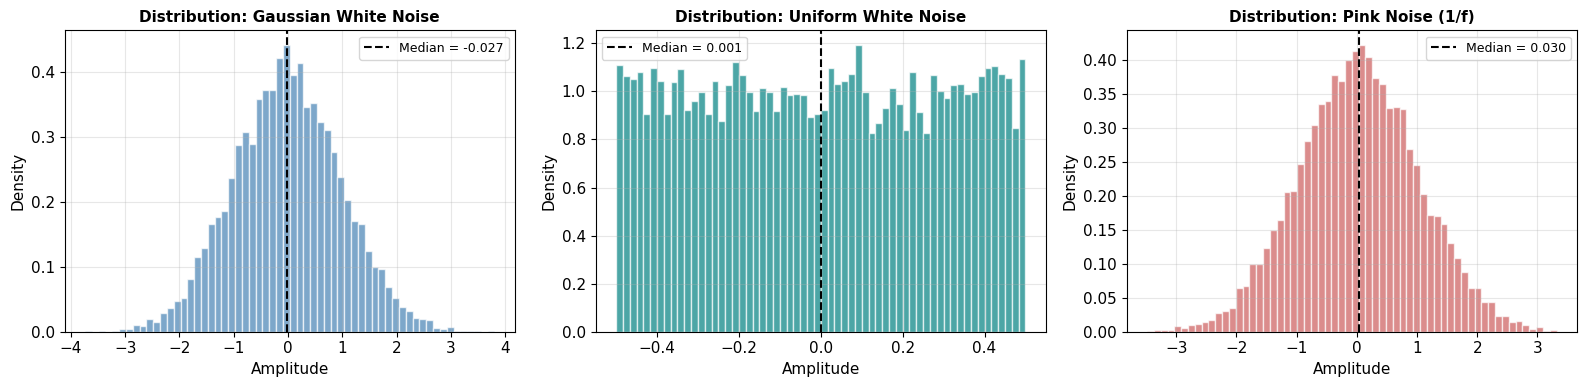

In [10]:
# Amplitude distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, noise, color) in zip(axes, noises):
    ax.hist(noise, bins=60, density=True, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.median(noise), color='black', linestyle='--', linewidth=1.5,
               label=f'Median = {np.median(noise):.3f}')
    ax.set_title(f'Distribution: {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 6. Sampling Rate & Resolution
---

### Sampling Rate (Temporal Resolution)

The sampling rate determines how finely we slice time:

| Sampling Rate | Time per Sample | Typical Use |
|---|---|---|
| 256 Hz | 3.9 ms | Standard EEG |
| 500 Hz | 2.0 ms | Clinical EEG |
| 1000 Hz | 1.0 ms | Research EEG (convenient: 1 sample = 1 ms) |
| 2000+ Hz | < 0.5 ms | Simultaneous EEG + fMRI |

**500-2000 Hz covers most EEG analysis.** 1000 Hz is particularly convenient since each sample corresponds to exactly 1 millisecond.

### The Nyquist Theorem

You must sample at **at least twice** the highest frequency in the signal to avoid **aliasing**:

$$f_s \geq 2 \times f_{\max}$$

If the highest frequency in your EEG is 100 Hz, you need at least 200 Hz sampling. In practice, we use much higher rates to provide a safety margin.

### Temporal Precision
How much information is encoded across the current, previous, and next time points. Higher sampling rates capture finer temporal details.

### Frequency Resolution
Determined by the **total number of time points** — more samples yields finer frequency bins in spectral analysis:

$$\Delta f = \frac{f_s}{N}$$

where $N$ is the total number of samples.

### Frequency Precision
The information density per frequency bin relative to the whole signal. Longer recordings give more precise frequency estimates.

In [11]:
# Interactive: visualize aliasing and the Nyquist theorem
def plot_aliasing(signal_freq=5.0, sampling_rate=12):
    # "True" continuous signal
    t_cont = np.arange(0, 2, 0.0001)
    s_cont = np.sin(2 * np.pi * signal_freq * t_cont)

    # Sampled version
    t_samp = np.arange(0, 2, 1/sampling_rate)
    s_samp = np.sin(2 * np.pi * signal_freq * t_samp)

    # Nyquist limit
    nyquist = sampling_rate / 2
    aliased = signal_freq > nyquist

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_cont, s_cont, color='steelblue', linewidth=1.2, alpha=0.5,
            label=f'True signal ({signal_freq} Hz)')
    ax.stem(t_samp, s_samp, linefmt='red' if aliased else 'green',
            markerfmt='ro' if aliased else 'go', basefmt='gray',
            label=f'Samples (fs={sampling_rate} Hz)')

    # If aliased, show what frequency the samples "look like"
    if aliased:
        apparent_freq = abs(signal_freq - sampling_rate * round(signal_freq / sampling_rate))
        s_alias = np.sin(2 * np.pi * apparent_freq * t_cont)
        ax.plot(t_cont, s_alias, color='red', linewidth=1, linestyle='--',
                label=f'Aliased appearance ({apparent_freq:.1f} Hz)', alpha=0.7)

    status = 'ALIASED!' if aliased else 'Properly sampled'
    ax.set_title(f'Signal: {signal_freq} Hz  |  Nyquist limit: {nyquist} Hz  |  {status}', fontsize=13)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

interact(
    plot_aliasing,
    signal_freq=FloatSlider(min=1, max=50, step=1, value=5, description='Signal (Hz)'),
    sampling_rate=IntSlider(min=4, max=100, step=2, value=12, description='Fs (Hz)')
)

interactive(children=(FloatSlider(value=5.0, description='Signal (Hz)', max=50.0, min=1.0, step=1.0), IntSlide…

<function __main__.plot_aliasing(signal_freq=5.0, sampling_rate=12)>

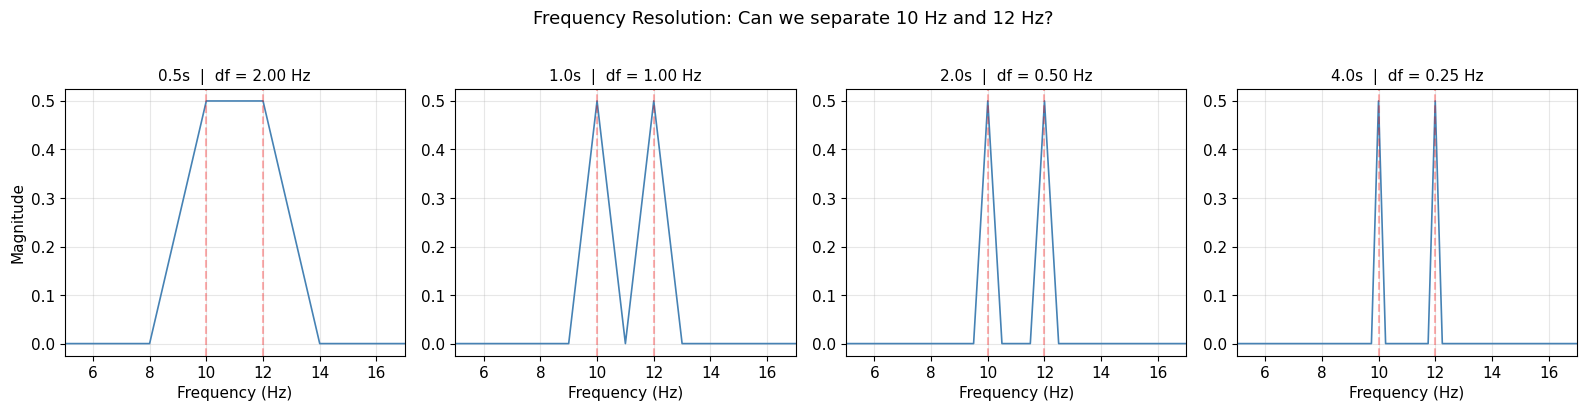

In [12]:
# Frequency resolution depends on signal length
fs = 256
durations = [0.5, 1.0, 2.0, 4.0]  # seconds

fig, axes = plt.subplots(1, len(durations), figsize=(16, 4))

for ax, dur in zip(axes, durations):
    t = np.arange(0, dur, 1/fs)
    # Signal with two close frequencies: 10 Hz and 12 Hz
    s = np.sin(2 * np.pi * 10 * t) + np.sin(2 * np.pi * 12 * t)

    # FFT
    N = len(t)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_mag = np.abs(np.fft.rfft(s)) / N
    delta_f = fs / N

    ax.plot(freqs, fft_mag, color='steelblue', linewidth=1.2)
    ax.set_xlim(5, 17)
    ax.set_title(f'{dur}s  |  df = {delta_f:.2f} Hz', fontsize=11)
    ax.set_xlabel('Frequency (Hz)')
    ax.axvline(10, color='red', alpha=0.3, linestyle='--')
    ax.axvline(12, color='red', alpha=0.3, linestyle='--')

axes[0].set_ylabel('Magnitude')
fig.suptitle('Frequency Resolution: Can we separate 10 Hz and 12 Hz?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 7. The Sine Wave
---

The sine wave is the fundamental building block of signal processing. Every signal can be decomposed into a sum of sine waves (this is the core idea of the Fourier Transform).

### General Formula

$$y = a \times \sin(2\pi \times f \times t + \theta)$$

where:
- $a$ is the **amplitude** (peak height),
- $f$ is the **frequency** in Hz (cycles per second),
- $t$ is **time** in seconds,
- $\theta$ is the **phase angle** in radians.

### Sine vs Cosine

A cosine is just a **phase-shifted sine**:
- $\theta = 0$: **sine** — starts at zero, rises first
- $\theta = \pi/2$: **cosine** — starts at the peak

$$\cos(t) = \sin\left(t + \frac{\pi}{2}\right)$$

In [ ]:
# Single sine wave with labeled parameters
fs = 256
t = np.arange(0, 5, 1/fs)

a = 10      # amplitude
f = 3       # frequency (Hz)
p = np.pi/2 # phase (radians) -- this makes it a cosine

s = a * np.sin(2 * np.pi * f * t + p)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, s, color='steelblue', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(a, color='red', linestyle='--', alpha=0.5, label=f'Amplitude = {a}')
ax.axhline(-a, color='red', linestyle='--', alpha=0.5)

T = 1/f
ax.annotate('', xy=(0, -a-1), xytext=(T, -a-1),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text(T/2, -a-1.8, f'T = {T:.3f} s', ha='center', color='orange', fontsize=11, fontweight='bold')

ax.set_title(f'y = {a} * sin(2pi * {f} * t + pi/2)  -->  This is a cosine!', fontsize=13)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Superposition: adding multiple sine waves
fs = 256
t = np.arange(0, 2 * np.pi, 1/fs)

amplitudes  = [10, 5, 2]
frequencies = [2, 5, 10]
phases      = [0, np.pi, np.pi/2]
colors      = ['#e74c3c', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(len(amplitudes) + 1, 1, figsize=(12, 10), sharex=True)

composite = np.zeros(len(t))
for i, (a, f, p, c) in enumerate(zip(amplitudes, frequencies, phases, colors)):
    component = a * np.sin(2 * np.pi * f * t + p)
    composite += component
    axes[i].plot(t, component, color=c, linewidth=1.2)
    axes[i].set_title(f'Component {i+1}: a={a}, f={f} Hz, phase={p:.2f} rad', fontsize=11)
    axes[i].set_ylabel('Amplitude')

axes[-1].plot(t, composite, color='steelblue', linewidth=1.5)
axes[-1].set_title('Composite Signal (sum of all components)', fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Time (s)')
axes[-1].set_ylabel('Amplitude')

fig.suptitle('Superposition Principle: Complex Signals = Sum of Simple Sinusoids', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 8. Euler's Formula & Complex Exponentials
---

### Euler's Formula

One of the most beautiful equations in mathematics connects exponentials, trigonometry, and complex numbers:

$$e^{ik} = \cos(k) + i\sin(k)$$

This means a complex exponential traces a **circle** in the complex plane as $k$ increases. The real part gives a cosine, the imaginary part gives a sine — both emerge from the same underlying rotation.

### Why Does This Matter for Signal Processing?

Euler's formula lets us express sines and cosines as complex exponentials:

$$\sin(t) = \frac{e^{it} - e^{-it}}{2i} = \text{Im}(e^{it})$$

$$\cos(t) = \frac{e^{it} + e^{-it}}{2} = \text{Re}(e^{it})$$

This is **not** just mathematical elegance — it's the reason the **Fourier Transform** works. Complex exponentials are the natural basis functions for decomposing signals. They make convolutions into multiplications, differentiation into multiplication by $i\omega$, and generally turn hard problems into easy ones.

### The Complex Sine Wave

Substituting the standard oscillation formula into Euler's formula gives:

$$y = e^{i \cdot 2\pi f t} = \underbrace{\cos(2\pi f t)}_{\text{real part}} + i \underbrace{\sin(2\pi f t)}_{\text{imaginary part}}$$

The real and imaginary parts are a **cosine and a sine**, offset by $\pi/2$. When plotted in 3D (time x real x imaginary), this traces a **helix** — a corkscrew through the complex plane.

In [ ]:
# Euler's formula: complex exponential traces a circle
theta = np.linspace(0, 2 * np.pi, 500)
z = np.exp(1j * theta)  # e^(i*theta)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Unit circle in complex plane
axes[0].plot(z.real, z.imag, color='steelblue', linewidth=2)
key_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
key_labels = [r'$e^{i0}=1$', r'$e^{i\pi/2}=i$', r'$e^{i\pi}=-1$', r'$e^{i3\pi/2}=-i$']
for angle, label in zip(key_angles, key_labels):
    pt = np.exp(1j * angle)
    axes[0].plot(pt.real, pt.imag, 'ro', markersize=8)
    axes[0].annotate(label, (pt.real, pt.imag), textcoords='offset points',
                     xytext=(10, 10), fontsize=10, color='red')
axes[0].set_title(r'$e^{i\theta}$ traces the unit circle', fontsize=12)
axes[0].set_xlabel('Real (cosine)')
axes[0].set_ylabel('Imaginary (sine)')
axes[0].set_aspect('equal')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)

# Real part = cosine
axes[1].plot(theta, z.real, color='#e74c3c', linewidth=1.5)
axes[1].set_title(r'Real part: $\cos(\theta)$', fontsize=12)
axes[1].set_xlabel('theta (radians)')
axes[1].set_ylabel('Amplitude')

# Imaginary part = sine
axes[2].plot(theta, z.imag, color='#2ecc71', linewidth=1.5)
axes[2].set_title(r'Imaginary part: $\sin(\theta)$', fontsize=12)
axes[2].set_xlabel('theta (radians)')
axes[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
# 3D helix: the complex sine wave
from mpl_toolkits.mplot3d import Axes3D

f = 3  # Hz
t = np.linspace(0, 2, 1000)
z = np.exp(1j * 2 * np.pi * f * t)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# 3D helix
ax.plot(t, z.real, z.imag, color='steelblue', linewidth=1.5, label='Complex exponential')

# Projections
ax.plot(t, z.real, zs=-1.5, zdir='z', color='#e74c3c', alpha=0.4, linewidth=1, label='Real part (cosine)')
ax.plot(t, z.imag * 0 - 0.1, z.imag, zdir='y', color='#2ecc71', alpha=0.4, linewidth=1, label='Imag part (sine)')

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Real (cos)', fontsize=10)
ax.set_zlabel('Imaginary (sin)', fontsize=10)
ax.set_title(f'Complex Sine Wave at {f} Hz -- a helix in 3D', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# 9. The Gaussian Function
---

The Gaussian function is a symmetric, **bell-shaped curve** that appears everywhere in signal processing and statistics.

### Mathematical Formulation

$$f(x) = a \times e^{-\frac{(x - b)^2}{2c^2}}$$

where:
- $a$ controls the **peak height**,
- $b$ determines the **position** of the peak along the x-axis (the center/mean),
- $c$ controls the **width** of the curve (related to the standard deviation).

### Why is the Gaussian Special?

1. **Self-similar under Fourier Transform:** A Gaussian in the time domain is also a Gaussian in the frequency domain. This makes it the optimal trade-off between time and frequency localization.
2. **Central Limit Theorem:** The sum of many independent random variables converges to a Gaussian, which is why noise is often Gaussian.

### Applications in EEG Analysis

| Application | How Gaussians are used |
|---|---|
| **Wavelet Transform** | Gaussian-derived wavelets (e.g., **Morlet wavelet**) balance time and frequency resolution |
| **Smoothing** | Gaussian kernels smooth EEG signals, reducing noise while preserving features |
| **Gaussian Filtering** | Removes high-frequency noise by weighting nearby samples with a Gaussian kernel |
| **Wavelet Analysis (CWT)** | A Gaussian-modulated complex sinusoid (Morlet wavelet) decomposes EEG into time-frequency components |

In [ ]:
# Interactive Gaussian exploration
def plot_gaussian(peak_height=1.0, center=0.0, width=1.0):
    x = np.linspace(-10, 10, 1000)
    g = peak_height * np.exp(-((x - center)**2) / (2 * width**2))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, g, color='steelblue', linewidth=2)
    ax.fill_between(x, g, alpha=0.15, color='steelblue')

    # Mark width (standard deviation)
    ax.axvline(center - width, color='red', linestyle='--', alpha=0.5,
               label=f'+/- sigma = +/- {width:.1f}')
    ax.axvline(center + width, color='red', linestyle='--', alpha=0.5)
    ax.axvline(center, color='orange', linestyle='-', alpha=0.5, label=f'Center = {center:.1f}')

    ax.set_title(f'Gaussian: a={peak_height:.1f}, b={center:.1f}, c={width:.1f}', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(0, 5.5)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

interact(
    plot_gaussian,
    peak_height=FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Height (a)'),
    center=FloatSlider(min=-5, max=5, step=0.5, value=0.0, description='Center (b)'),
    width=FloatSlider(min=0.2, max=5, step=0.2, value=1.0, description='Width (c)')
)

In [ ]:
# Morlet wavelet: a Gaussian-windowed complex sinusoid
# This is the key connection between Gaussians and EEG analysis

t = np.linspace(-3, 3, 1000)
freq = 2  # Hz (center frequency of wavelet)
sigma = 0.8  # width of Gaussian envelope

# Components
gaussian_env = np.exp(-t**2 / (2 * sigma**2))
sine_wave = np.cos(2 * np.pi * freq * t)  # real part
morlet = gaussian_env * sine_wave  # Morlet wavelet (real part)
morlet_imag = gaussian_env * np.sin(2 * np.pi * freq * t)  # imaginary part

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0, 0].plot(t, gaussian_env, color='orange', linewidth=2)
axes[0, 0].fill_between(t, gaussian_env, alpha=0.1, color='orange')
axes[0, 0].set_title('Gaussian Envelope', fontsize=12, fontweight='bold')

axes[0, 1].plot(t, sine_wave, color='steelblue', linewidth=1.5)
axes[0, 1].set_title(f'Cosine Wave ({freq} Hz)', fontsize=12, fontweight='bold')

axes[1, 0].plot(t, morlet, color='teal', linewidth=2)
axes[1, 0].plot(t, gaussian_env, color='orange', linewidth=1, linestyle='--', alpha=0.6)
axes[1, 0].plot(t, -gaussian_env, color='orange', linewidth=1, linestyle='--', alpha=0.6)
axes[1, 0].set_title('Morlet Wavelet (real) = Gaussian x Cosine', fontsize=12, fontweight='bold')

axes[1, 1].plot(t, morlet_imag, color='#9b59b6', linewidth=2)
axes[1, 1].plot(t, gaussian_env, color='orange', linewidth=1, linestyle='--', alpha=0.6)
axes[1, 1].plot(t, -gaussian_env, color='orange', linewidth=1, linestyle='--', alpha=0.6)
axes[1, 1].set_title('Morlet Wavelet (imag) = Gaussian x Sine', fontsize=12, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

fig.suptitle('Building the Morlet Wavelet -- the workhorse of EEG time-frequency analysis',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 10. Energy and Power
---

Understanding energy and power is essential for spectral analysis — when we talk about the "power spectrum" of an EEG signal, these are the quantities we mean.

### Instantaneous Power

At any moment, the **instantaneous power** is the square of the signal's amplitude:

$$P(t) = s^2(t)$$

This tells us "how much energy is being delivered right now." Note that squaring makes all values positive — power is always non-negative.

### Signal Energy

The **total energy** over a time interval is the integral (or sum, for discrete signals) of instantaneous power:

$$E = \int s^2(t) \, dt = \sum_{i=1}^{N} |s_i|^2$$

This is the area under the squared signal — equivalently, the total "work" done by the signal.

### Average Power

For a signal of duration $T$:

$$\bar{P} = \frac{1}{T} \int_0^T s^2(t) \, dt = \frac{E}{T}$$

Note that **RMS amplitude** = $\sqrt{\bar{P}}$, which connects our earlier discussion to power.

### Connection to Frequency Domain

**Parseval's theorem** states that the total energy computed in the time domain equals the total energy computed in the frequency domain. This is why we can meaningfully talk about "power at 10 Hz" — it corresponds to actual signal energy.

In [ ]:
# Visualize instantaneous power, energy, and average power
np.random.seed(42)
fs = 256
t = np.arange(0, 3, 1/fs)

# EEG-like signal: alpha with amplitude modulation
envelope = 1 + 2 * np.exp(-((t - 1.5)**2) / (2 * 0.3**2))
signal = envelope * np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))

# Compute quantities
inst_power = signal**2
cumulative_energy = np.cumsum(inst_power) / fs  # approximate integral
total_energy = cumulative_energy[-1]
avg_power = total_energy / (t[-1] - t[0])
rms = np.sqrt(avg_power)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Signal
axes[0].plot(t, signal, color='steelblue', linewidth=0.8)
axes[0].axhline(rms, color='green', linestyle='--', label=f'RMS = {rms:.2f}')
axes[0].axhline(-rms, color='green', linestyle='--')
axes[0].set_title('Signal $s(t)$', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (uV)')
axes[0].legend(fontsize=10)

# Instantaneous power
axes[1].fill_between(t, inst_power, alpha=0.3, color='orange')
axes[1].plot(t, inst_power, color='orange', linewidth=0.6)
axes[1].axhline(avg_power, color='red', linestyle='--', linewidth=1.5,
                label=f'Avg power = {avg_power:.2f} uV^2')
axes[1].set_title('Instantaneous Power $P(t) = s^2(t)$', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Power (uV^2)')
axes[1].legend(fontsize=10)

# Cumulative energy
axes[2].fill_between(t, cumulative_energy, alpha=0.2, color='teal')
axes[2].plot(t, cumulative_energy, color='teal', linewidth=1.5)
axes[2].set_title(f'Cumulative Energy -- Total E = {total_energy:.2f} uV^2*s', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Energy (uV^2*s)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print(f'Total Energy:   {total_energy:.3f} uV^2*s')
print(f'Average Power:  {avg_power:.3f} uV^2')
print(f'RMS Amplitude:  {rms:.3f} uV (= sqrt(avg_power))')

In [ ]:
# Parseval's theorem: energy in time domain = energy in frequency domain
np.random.seed(42)
fs = 256
t = np.arange(0, 4, 1/fs)
signal = (
    2 * np.sin(2 * np.pi * 10 * t)
    + 1 * np.sin(2 * np.pi * 22 * t)
    + 0.5 * np.random.randn(len(t))
)

N = len(signal)

# Time domain energy
energy_time = np.sum(signal**2)

# Frequency domain energy (Parseval's theorem)
fft_vals = np.fft.fft(signal)
energy_freq = np.sum(np.abs(fft_vals)**2) / N

# Power spectrum
freqs = np.fft.rfftfreq(N, 1/fs)
power_spectrum = (2.0 / N) * np.abs(np.fft.rfft(signal))**2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, signal, color='steelblue', linewidth=0.6)
axes[0].set_title(f'Time Domain  |  Energy = {energy_time:.1f}', fontsize=12)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (uV)')

axes[1].plot(freqs, power_spectrum, color='orange', linewidth=1.2)
axes[1].set_title(f'Power Spectrum  |  Energy = {energy_freq:.1f}', fontsize=12)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power (uV^2/Hz)')
axes[1].set_xlim(0, 50)

fig.suptitle("Parseval's Theorem: Energy is conserved across domains", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Time-domain energy:      {energy_time:.2f}')
print(f'Frequency-domain energy: {energy_freq:.2f}')
print(f'Match: {np.isclose(energy_time, energy_freq, rtol=1e-10)}')

---

# Summary

| Concept | Key Takeaway |
|---|---|
| **Signal** | A quantity measured at regular intervals -- continuous or discrete |
| **Sampling Rate** | Samples per second; must be >= 2x max frequency (Nyquist) |
| **Frequency & Period** | $f = 1/T$; frequency in Hz, period in seconds |
| **Oscillation Properties** | Fully described by frequency, amplitude, and phase |
| **Amplitude Measures** | Peak (spikes), Peak-to-Peak (variability), RMS (effective power) |
| **Noise** | White (flat spectrum), Pink (1/f -- common in biology) |
| **Sine Wave** | $y = a \sin(2\pi f t + \theta)$ -- the building block of all signals |
| **Euler's Formula** | $e^{ik} = \cos(k) + i\sin(k)$ -- foundation of Fourier analysis |
| **Complex Sinusoid** | Helix in complex plane; real part = cosine, imaginary = sine |
| **Gaussian** | Bell curve; optimal time-frequency localization; basis of Morlet wavelet |
| **Energy & Power** | $P = s^2(t)$, $E = \int s^2(t)\,dt$; Parseval's theorem connects time and frequency |

These concepts form the foundation for everything that follows -- filtering, spectral analysis, wavelet transforms, and EEG-specific processing techniques.

---

*Next: Introduction to EEG Signals*